In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
plt.style.use('ggplot')

In [3]:
# Original XOR dataset in 2D
X = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1]])
y = np.array([1, 1, -1, -1])

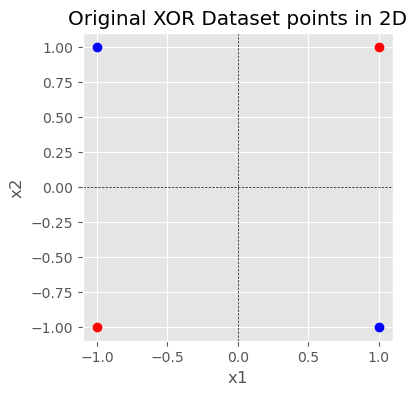

In [4]:
# Plotting the 2D points
plt.figure(figsize=(4,4))

for i, label in enumerate(y):
    plt.plot(X[i, 0], X[i, 1], 'ro' if label == 1 else 'bo')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Original XOR Dataset points in 2D')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(True)

In [5]:
# Applying feature transformation to 3D: x3 = x1 * x2
X_transformed = np.hstack((X, (X[:, 0] * X[:, 1]).reshape(-1, 1)))

# Create a Plotly figure
fig = go.Figure()

# Add points to the plot
colors = ['red' if label ==1 else 'blue' for label in y]
fig.add_trace(go.Scatter3d(x=X_transformed[:, 0], y=X_transformed[:, 1], z=X_transformed[:, 2], mode='markers', marker=dict(color=colors, size=5), text=['(1,1,1)', '(-1,-1,1)', '(1,-1,-1)', '(-1,1,-1)'], name='Data Points', showlegend=False, opacity=0.8))

# Define the separator plane
xx, yy = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(-2, 2, 50))
zz = np.zeros_like(xx)  # 0 * xx
fig.add_trace(go.Surface(x=xx, y=yy, z=zz, colorscale='Greens', opacity=0.5))

# Set the layout for the better view
fig.update_layout(title='Transformed XOR points in 3D with separator', scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='x3=x1*x2'), margin=dict(l=0, r=0, b=0, t=30))

In [6]:
# This is a more general version of the above function that can handle any number of features and expand them to a given degree. But has not been implemented here.

def expand_features(X, degree):
    from itertools import combinations_with_replacement
    n_samples, n_features = X.shape
    combos = list(combinations_with_replacement(range(n_features), degree))
    X_expanded = np.ones((n_samples, len(combos)))
    for i, combo in enumerate(combos):
        for index in combo:
            X_expanded[:, i] *= X[:, index]
    return X_expanded

In [7]:
# More robust polynomial basis featurization technique
def expand_features_degree_n(X, degree):
    from itertools import combinations_with_replacement
    m_feature_samples, n_feature_components = X.shape
    X_expanded = np.full((m_feature_samples, 1), "1", dtype='object')
    for deg in range(1, degree+1):
        combos = list(combinations_with_replacement(range(n_feature_components), deg))
        X_interim = np.full((m_feature_samples, len(combos)), "", dtype='object')
        
        for itr, combo in enumerate(combos):
            for idx in combo:
                X_interim[:, itr] += X[:, idx]

        X_expanded = np.hstack((X_expanded, X_interim))
        
    return X_expanded

_X = np.array([["x1", "x2", "x3"]])
print(expand_features_degree_n(_X, 2))

[['1' 'x1' 'x2' 'x3' 'x1x1' 'x1x2' 'x1x3' 'x2x2' 'x2x3' 'x3x3']]


### Another Feature Representation methods

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)

print("Original features:", X[0])  # [2, 3]
print("Polynomial features:", X_poly[0])  # [1, 2, 3, 4, 6, 9]
#                                         [1, x₁, x₂, x₁², x₁x₂, x₂²]

# Fit linear model to polynomial features
model = LinearRegression()
model.fit(X_poly, y)

# Result: polynomial curve fitted using linear regression

Original features: [1 1]
Polynomial features: [1. 1. 1. 1. 1. 1.]


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scale features before polynomial transformation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_poly = poly.fit_transform(X_scaled)